# Activity 1: Exploratory Data Analysis (EDA) - Job Search and Application Optimizer based on AI

## Job Description Dataset

This notebook presents an exploratory data analysis of a job listings dataset. The goal is to understand the structure, identify data quality issues, and extract meaningful insights to support further modeling.

Class: TC5035.10
Team: 60

- Main proposal: https://docs.google.com/document/d/1Mz4UCXaHjD5owqZ2oFoiThBTcC2Dnv-DvTM3Rf65L58/edit?tab=t.0
- Dataset: https://www.kaggle.com/datasets/ravindrasinghrana/job-description-dataset

In [70]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.ensemble import RandomForestRegressor

sns.set(style="whitegrid")

In [2]:
pd.set_option('display.max_colwidth', None)

In [3]:
df = pd.read_csv("../data/input/job_descriptions.csv")
df.head()

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","{'Flexible Spending Accounts (FSAs), Relocation Assistance, Legal Assistance, Employee Recognition Programs, Financial Counseling'}","Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising","Manage and grow social media accounts, create engaging content, and interact with the online community. Develop social media content calendars and strategies. Monitor social media trends and engagement metrics.",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversified Financials"",""City"":""Sunny Isles Beach"",""State"":""Florida"",""Zip"":""33160"",""Website"":""www.ielp.com"",""Ticker"":""IEP"",""CEO"":""David Willetts""}"
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.","{'Health Insurance, Retirement Plans, Paid Time Off (PTO), Flexible Work Arrangements, Employee Assistance Programs (EAP)'}","HTML, CSS, JavaScript Frontend frameworks (e.g., React, Angular) User experience (UX)","Design and code user interfaces for websites, ensuring a seamless and visually appealing user experience. Collaborate with UX designers to optimize user journeys. Ensure cross-browser compatibility and responsive design.",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Commercial Banks"",""City"":""Pittsburgh"",""State"":""Pennsylvania"",""Zip"":""15222"",""Website"":""www.pnc.com"",""Ticker"":""PNC"",""CEO"":""William S. Demchak""}"
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.","{'Legal Assistance, Bonuses and Incentive Programs, Wellness Programs, Employee Discounts, Retirement Plans'}","Quality control processes and methodologies Statistical process control (SPC) Root cause analysis and corrective action Quality management systems (e.g., ISO 9001) Compliance and regulatory knowledge",Establish and enforce quality control standards and procedures. Conduct quality audits and inspections. Collaborate with production teams to address quality issues and implement improvements.,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: Property and Casualty (Stock)"",""City"":""San Antonio"",""State"":""Texas"",""Zip"":""78288"",""Website"":""www.usaa.com"",""Ticker"":"""",""CEO"":""Wayne Peacock""}"
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.","{'Transportation Benef

This dataset provides a comprehensive collection of synthetic job postings to facilitate research and analysis in the field of job market trends, natural language processing (NLP), and machine learning. Created for educational and research purposes, this dataset offers a diverse set of job listings across various industries and job types.


Descriptions for each of the columns in the dataset:


- Job Id: A unique identifier for each job posting.
- Experience: The required or preferred years of experience for the job.
- Qualifications: The educational qualifications needed for the job.
- Salary Range: The range of salaries or compensation offered for the position.
- Location: The city or area where the job is located.
- Country: The country where the job is located.
- Latitude: The latitude coordinate of the job location.
- Longitude: The longitude coordinate of the job location.
- Work Type: The type of employment (e.g., full-time, part-time, contract).
- Company Size: The approximate size or scale of the hiring company.
- Job Posting Date: The date when the job posting was made public.
- Preference: Special preferences or requirements for applicants (e.g., Only Male or Only Female, or Both)
- Contact Person: The name of the contact person or recruiter for the job.
- Contact: Contact information for job inquiries.
- Job Title: The job title or position being advertised.
- Role: The role or category of the job (e.g., software developer, marketing manager).
- Job Portal: The platform or website where the job was posted.
- Job Description: A detailed description of the job responsibilities and requirements.
- Benefits: Information about benefits offered with the job (e.g., health insurance, retirement plans).
- Skills: The skills or qualifications required for the job.
- Responsibilities: Specific responsibilities and duties associated with the job.
- Company Name: The name of the hiring company.
- Company Profile: A brief overview of the company's background and mission.

## Data Structure Overview

We analyze the shape, data types, and general structure of the dataset.

In [4]:
df.shape

(1615940, 23)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1615940 entries, 0 to 1615939
Data columns (total 23 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Job Id            1615940 non-null  int64  
 1   Experience        1615940 non-null  str    
 2   Qualifications    1615940 non-null  str    
 3   Salary Range      1615940 non-null  str    
 4   location          1615940 non-null  str    
 5   Country           1615940 non-null  str    
 6   latitude          1615940 non-null  float64
 7   longitude         1615940 non-null  float64
 8   Work Type         1615940 non-null  str    
 9   Company Size      1615940 non-null  int64  
 10  Job Posting Date  1615940 non-null  str    
 11  Preference        1615940 non-null  str    
 12  Contact Person    1615940 non-null  str    
 13  Contact           1615940 non-null  str    
 14  Job Title         1615940 non-null  str    
 15  Role              1615940 non-null  str    
 16  Job Portal 

The dataset shows a high level of completeness across its attributes, as almost all columns contain the full set of non-null records. Out of the 23 available columns and a total of 1,615,940 entries, only the Company Profile column contains missing values, with 1,610,462 non-null records. This minimal amount of missing data is likely due to the fact that the dataset is synthetic, meaning it was artificially generated and designed to maintain a high level of consistency and completeness across most variables.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Job Id,1615940.0,1.548935e+15,8.946722e+14,1.817948e+11,7.740508e+14,1.547858e+15,2.323729e+15,3.099618e+15
latitude,1615940.0,1.937743e+01,2.355690e+01,-4.090060e+01,5.152100e+00,1.807080e+01,3.907420e+01,7.170690e+01
longitude,1615940.0,1.639926e+01,7.066762e+01,-1.751982e+02,-1.531010e+01,1.914510e+01,4.757690e+01,1.780650e+02
Company Size,1615940.0,7.370467e+04,3.529886e+04,1.264600e+04,4.311400e+04,7.363300e+04,1.043000e+05,1.348340e+05


In [7]:
df.describe(include="object").T

/var/folders/3m/mq9yd779097d0kvtn4rhg2480000gq/T/ipykernel_10629/1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
Experience,1615940,48,5 to 8 Years,34120
Qualifications,1615940,10,BBA,162148
Salary Range,1615940,561,$59K-$88K,3043
location,1615940,214,Seoul,15104
Country,1615940,216,Malta,7723
Work Type,1615940,5,Part-Time,324044
Job Posting Date,1615940,731,2021-11-14,2378
Preference,1615940,3,Male,539167
Contact Person,1615940,367128,Michael Smith,838
Contact,1615940,1615933,+1-507-963-5920,2


The statistical analysis shows that the dataset contains a large variety of job-related information with high diversity across most categorical variables.


For the numerical variable Company Size, the average company size is approximately 73,705 employees, with a standard deviation of 35,299, indicating a wide variation in company sizes. The smallest company in the dataset has around 12,646 employees, while the largest reaches 134,834 employees. The median value (73,633) is very close to the mean, suggesting a relatively balanced distribution.


Regarding categorical variables, the dataset contains 48 different experience categories, with “5 to 8 Years” being the most frequent. There are 10 qualification categories, where BBA appears most commonly. Salary ranges are highly diverse, with 561 unique salary intervals, although “$59K-$88K” is the most repeated range.


The dataset also demonstrates broad geographic coverage, including 214 unique locations and 216 countries, with Seoul and Malta appearing most frequently. For employment conditions, Part-Time positions are the most common work type, while Male is the most frequent preference category.


Job-related fields such as Job Title, Role, Job Description, Skills, and Responsibilities show a high diversity of professional profiles, although UX/UI Designer and Interaction Designer related entries appear most often. Similarly, FlexJobs is the most represented job portal in the dataset.


Finally, company-related information is also diverse, with 888 unique companies and 884 different company profiles. The most frequent company is DTE Energy, while the most common company profile corresponds to an automotive sector organization. Overall, these statistics suggest that the synthetic dataset was designed to simulate a broad and diverse job market environment.

In [8]:
df["desc_length"] = df["Job Description"].str.len()
df["skills_length"] = df["skills"].str.len()
df["resp_length"] = df["Responsibilities"].str.len()
df["skills_count"] = df["skills"].apply(lambda x: len(x.split(",")))

Feature extraction was applied to create new numerical variables from the text columns. The variables desc_length, skills_length, and resp_length measure the length of the job description, skills, and responsibilities text. 

Additionally, skills_count counts how many skills are listed in each job posting by separating the skills using commas. These new features help transform textual information into measurable data for analysis and modeling.

## Missing Values Analysis

We identify missing values and analyze their distribution.

In [9]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

Company Profile     5478
Job Id                 0
Job Title              0
resp_length            0
skills_length          0
desc_length            0
Company                0
Responsibilities       0
skills                 0
Benefits               0
Job Description        0
Job Portal             0
Role                   0
Contact                0
Experience             0
Contact Person         0
Preference             0
Job Posting Date       0
Company Size           0
Work Type              0
longitude              0
latitude               0
Country                0
location               0
Salary Range           0
Qualifications         0
skills_count           0
dtype: int64

In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

Company Profile     0.338998
Job Id              0.000000
Job Title           0.000000
resp_length         0.000000
skills_length       0.000000
desc_length         0.000000
Company             0.000000
Responsibilities    0.000000
skills              0.000000
Benefits            0.000000
Job Description     0.000000
Job Portal          0.000000
Role                0.000000
Contact             0.000000
Experience          0.000000
Contact Person      0.000000
Preference          0.000000
Job Posting Date    0.000000
Company Size        0.000000
Work Type           0.000000
longitude           0.000000
latitude            0.000000
Country             0.000000
location            0.000000
Salary Range        0.000000
Qualifications      0.000000
skills_count        0.000000
dtype: float64

The Company Profile column contains 5,478 missing values, representing only 0.34% of the total dataset.

## Categorical Variables Cardinality

We evaluate the number of unique values for categorical variables.

In [11]:
categorical_cols = df.select_dtypes(include=["object"]).columns

cardinality = {col: df[col].nunique() for col in categorical_cols}
cardinality

/var/folders/3m/mq9yd779097d0kvtn4rhg2480000gq/T/ipykernel_10629/4062489727.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


{'Experience': 48,
 'Qualifications': 10,
 'Salary Range': 561,
 'location': 214,
 'Country': 216,
 'Work Type': 5,
 'Job Posting Date': 731,
 'Preference': 3,
 'Contact Person': 367128,
 'Contact': 1615933,
 'Job Title': 147,
 'Role': 376,
 'Job Portal': 16,
 'Job Description': 376,
 'Benefits': 11,
 'skills': 376,
 'Responsibilities': 375,
 'Company': 888,
 'Company Profile': 884}

- Experience: 48 unique categories
- Qualifications: 10 unique categories
- Salary Range: 561 unique salary ranges
- Location: 214 unique locations
- Country: 216 unique countries
- Work Type: 5 work types
- Job Posting Date: 731 different posting dates
- Preference: 3 preference categories
- Contact Person: 367,128 unique contact persons
- Contact: 1,615,933 unique contact entries
- Job Title: 147 unique job titles
- Role: 376 unique roles
- Job Portal: 16 job portals
- Job Description: 376 unique descriptions
- Benefits: 11 benefit categories
- Skills: 376 unique skill sets
- Responsibilities: 375 unique responsibility descriptions
- Company: 888 unique companies
- Company Profile: 884 unique company profiles

## Univariate Analysis - Numerical Variables

In [12]:
numerical_cols = df.select_dtypes(include=np.number).columns.drop(["Job Id", "latitude", "longitude"])
numerical_cols

Index(['Company Size', 'desc_length', 'skills_length', 'resp_length',
       'skills_count'],
      dtype='str')

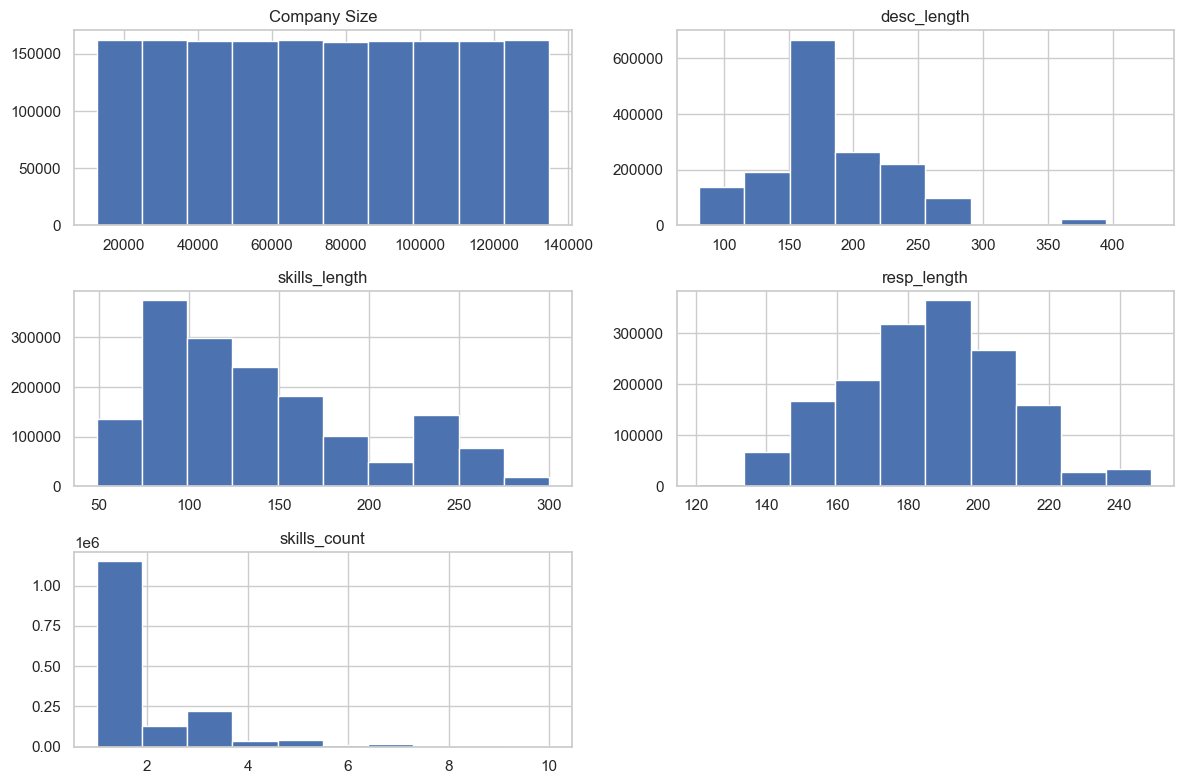

In [13]:
df[numerical_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [14]:
print(df[numerical_cols].skew())

Company Size     0.002142
desc_length      1.007489
skills_length    0.770081
resp_length     -0.017358
skills_count     2.691339
dtype: float64


The skewness analysis shows how the data is distributed for each numerical variable:
- Company Size (0.002) → Almost perfectly symmetric, meaning company sizes are evenly distributed around the mean.
- desc_length (1.007) → Positively skewed, indicating that most job descriptions are shorter, while a smaller number contain very long descriptions.
- skills_length (0.770) → Moderately positively skewed, showing that most skill descriptions have medium length, but some are significantly longer.
- resp_length (-0.017) → Nearly symmetric, meaning responsibility descriptions are distributed evenly without strong skewness.
- skills_count (2.691) → Highly positively skewed, indicating that most job postings list a small number of skills, while a few postings contain a very large number of skills.

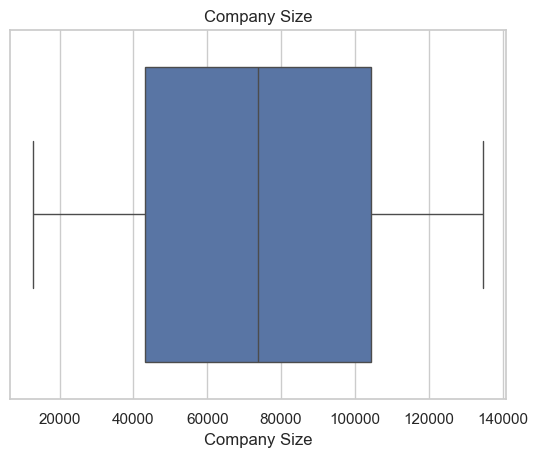

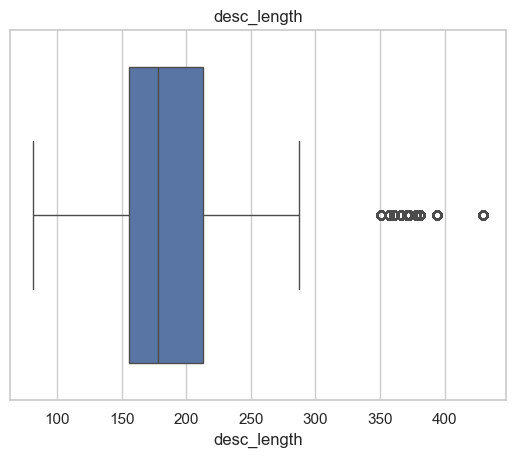

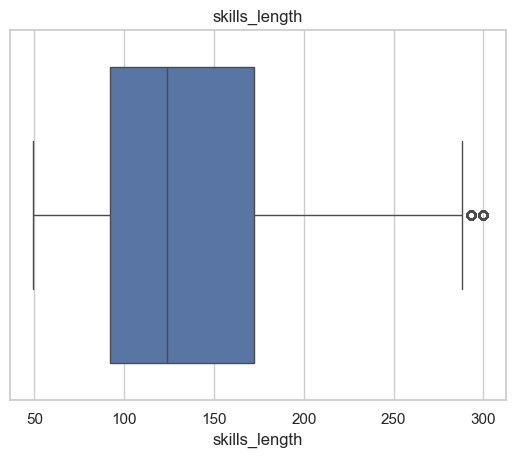

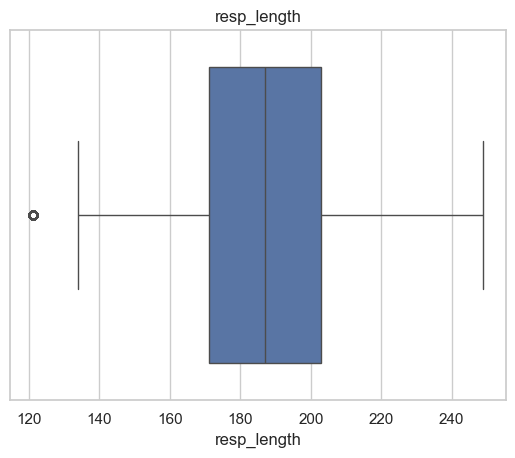

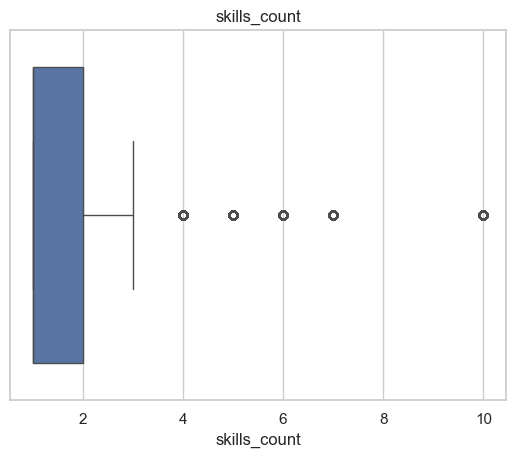

In [15]:
for col in numerical_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [16]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Company Size,1615940.0,73704.671546,35298.863912,12646.0,43114.0,73633.0,104300.0,134834.0
desc_length,1615940.0,185.368376,51.743614,81.0,156.0,178.0,213.0,430.0
skills_length,1615940.0,139.012857,58.885388,49.0,92.0,124.0,172.0,300.0
resp_length,1615940.0,186.002448,22.954288,121.0,171.0,187.0,203.0,249.0
skills_count,1615940.0,1.665803,1.317682,1.0,1.0,1.0,2.0,10.0


The numerical analysis shows that the dataset contains a wide range of values across the generated features.


- Company Size has an average of 73,705 employees, with values ranging from 12,646 to 134,834, indicating large variability in company sizes.
- desc_length has an average length of 185 characters, showing that most job descriptions are moderately detailed.
- skills_length has a mean of 139 characters, suggesting that skill descriptions are generally shorter than job descriptions.
- resp_length has an average of 186 characters with relatively low variability, meaning responsibility descriptions tend to have similar lengths across records.
- skills_count has an average of 1.67 skills per posting, with most jobs listing between 1 and 2 skills, although some postings include up to 10 skills.

Overall, the generated features show relatively balanced distributions, while Company Size presents the greatest variability among the numerical variables.

## Univariate Analysis - Categorical Variables

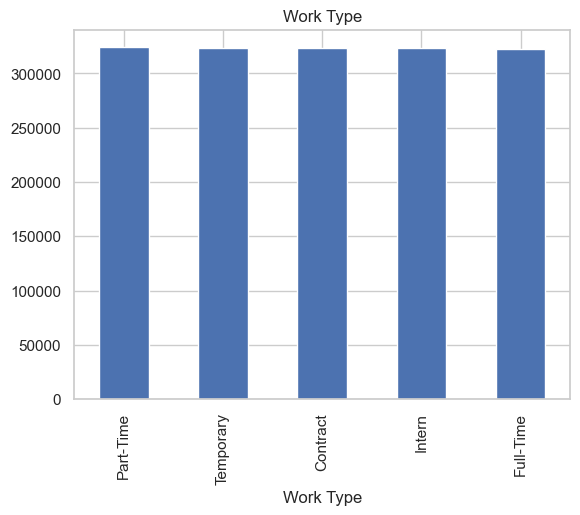

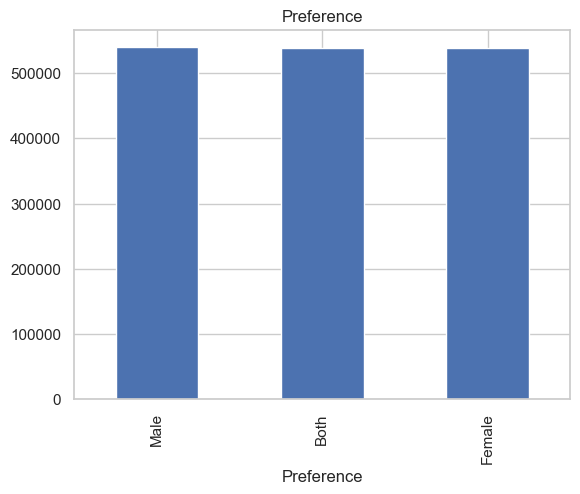

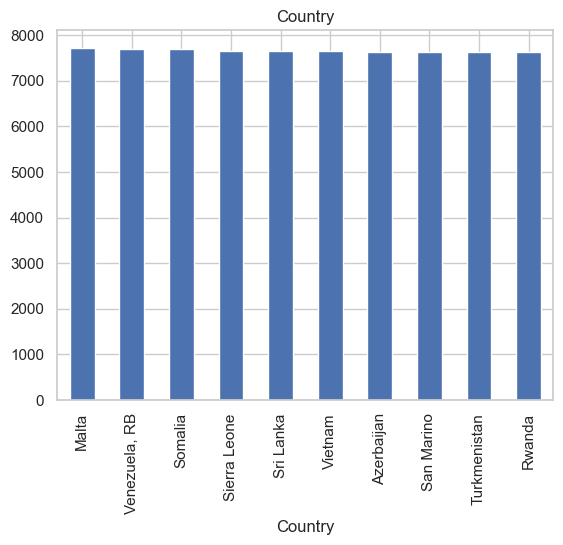

In [17]:
for col in ["Work Type", "Preference", "Country"]:
    plt.figure()
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(col)
    plt.show()

Data equally distributed

## Salary Cleaning

Salary ranges are transformed into numerical values for analysis.

In [18]:
def clean_salary(s):
    if pd.isna(s):
        return np.nan
    s = s.replace("$", "").replace("K", "000").replace("−", "-")
    parts = s.split("-")
    return (int(parts[0]) + int(parts[1])) / 2

df["Salary"] = df["Salary Range"].apply(clean_salary)

In [19]:
df["Salary"].head()

0    79000.0
1    86000.0
2    82500.0
3    78000.0
4    75500.0
Name: Salary, dtype: float64

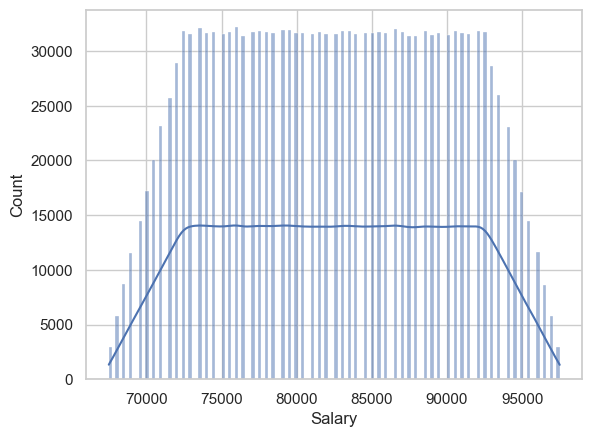

In [20]:
plt.figure()
sns.histplot(df["Salary"], kde=True)
plt.show()

In [21]:
print(df["Salary"].skew())

0.0016820310448981816


The skewness of the Salary variable is 0.0017, which is very close to zero. This indicates that salary values are almost perfectly symmetric and evenly distributed around the mean, with no significant skewness. This balanced distribution is likely due to the synthetic nature of the dataset.

In [22]:
def extract_experience(exp):
    exp = exp.replace("Years", "").strip()
    parts = exp.split("to")
    return (int(parts[0]) + int(parts[1])) / 2

df["Experience_num"] = df["Experience"].apply(extract_experience)

## Correlation Analysis

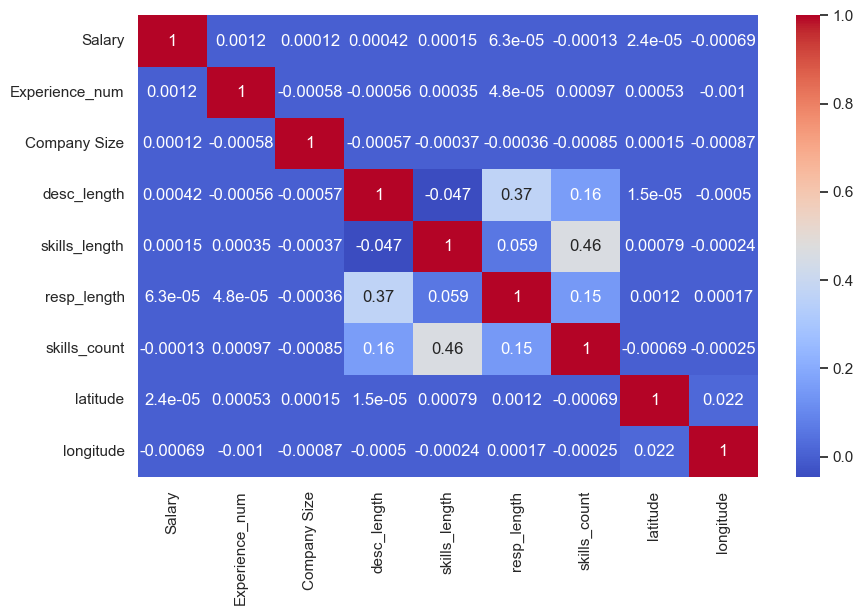

In [23]:
corr_cols = ["Salary", "Experience_num", "Company Size", "desc_length", "skills_length", "resp_length", "skills_count", "latitude", "longitude"]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

Weak correlations for the most part

## Geographic Distribution

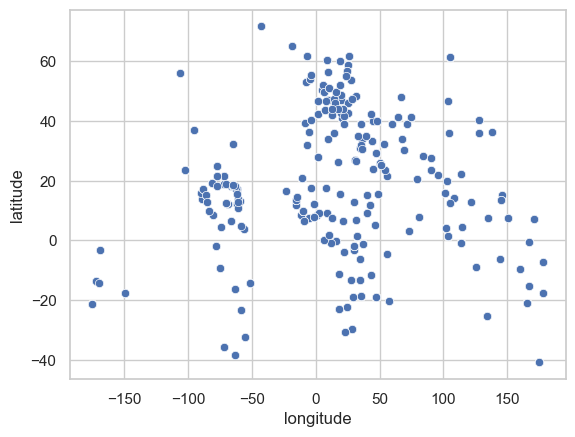

In [24]:
plt.figure()
sns.scatterplot(x=df["longitude"], y=df["latitude"])
plt.show()

In [25]:
# Add correlation against salary.
df[corr_cols].corr()["Salary"].sort_values(ascending=False)

Salary            1.000000
Experience_num    0.001214
desc_length       0.000420
skills_length     0.000148
Company Size      0.000124
resp_length       0.000063
latitude          0.000024
skills_count     -0.000127
longitude        -0.000691
Name: Salary, dtype: float64

In [26]:
# Compute high cardinality.
high_cardinality = {col: df[col].nunique() for col in categorical_cols if df[col].nunique() > 100}
high_cardinality

{'Salary Range': 561,
 'location': 214,
 'Country': 216,
 'Job Posting Date': 731,
 'Contact Person': 367128,
 'Contact': 1615933,
 'Job Title': 147,
 'Role': 376,
 'Job Description': 376,
 'skills': 376,
 'Responsibilities': 375,
 'Company': 888,
 'Company Profile': 884}

In [27]:
# Let's also add some encoding as well.
company_freq = df["Company"].value_counts().to_dict()
df["Company_freq"] = df["Company"].map(company_freq)

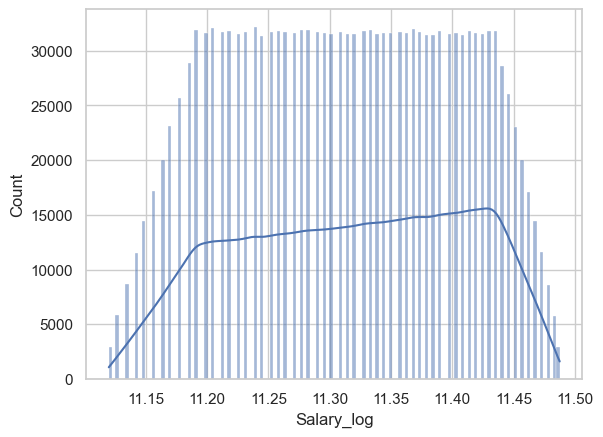

In [28]:
df["Salary_log"] = np.log1p(df["Salary"])

plt.figure()
sns.histplot(df["Salary_log"], kde=True)
plt.show()

In [29]:
print(df["Salary_log"].skew())

-0.12285972836767582


After applying the logarithmic transformation, the skewness of the Salary variable became -0.123, indicating a distribution that is still close to symmetric, but with a slight negative skew. This suggests that the logarithmic transformation helped maintain a balanced distribution while slightly reducing the influence of extreme salary values.

## Temporal Trends

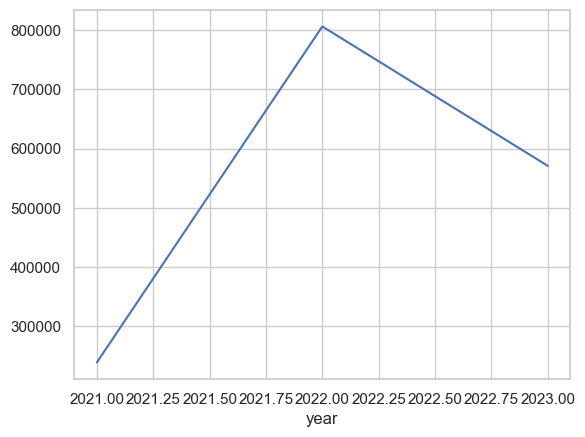

In [30]:
df["Job Posting Date"] = pd.to_datetime(df["Job Posting Date"])

df["year"] = df["Job Posting Date"].dt.year

df["year"].value_counts().sort_index().plot()
plt.show()

The job posting date that appears is from 2021-11-14 as a peak with 2378 repetitions

## Bivariate Analysis

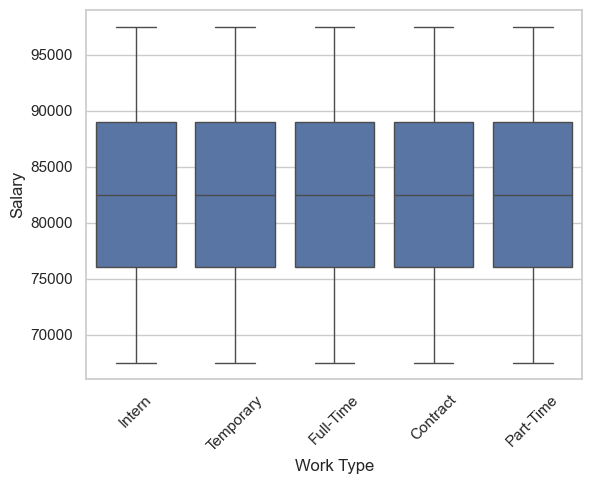

In [31]:
plt.figure()
sns.boxplot(x="Work Type", y="Salary", data=df)
plt.xticks(rotation=45)
plt.show()

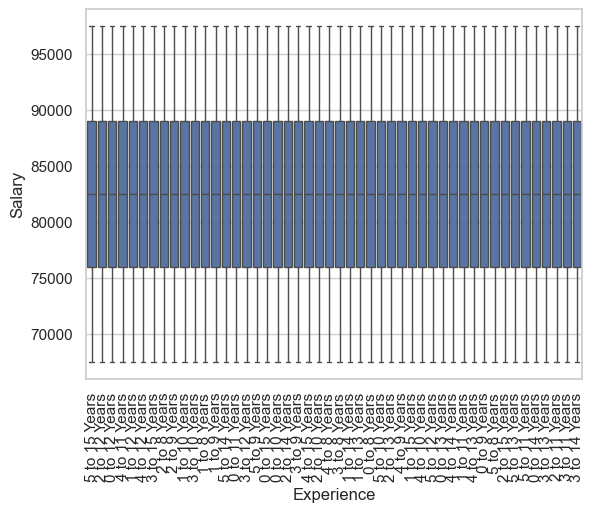

In [32]:
plt.figure()
sns.boxplot(x="Experience", y="Salary", data=df)
plt.xticks(rotation=90)
plt.show()

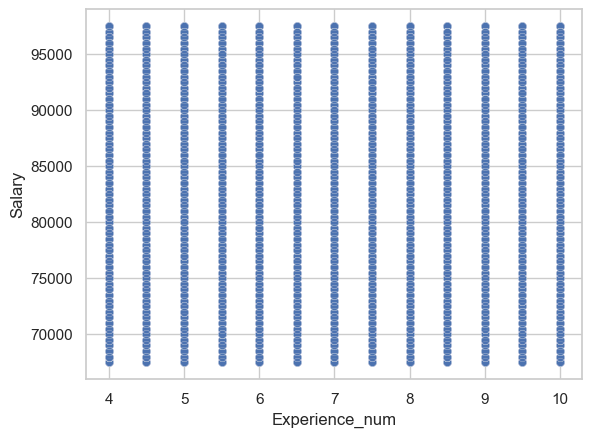

In [33]:
plt.figure()
sns.scatterplot(x="Experience_num", y="Salary", data=df, alpha=0.1)
plt.show()

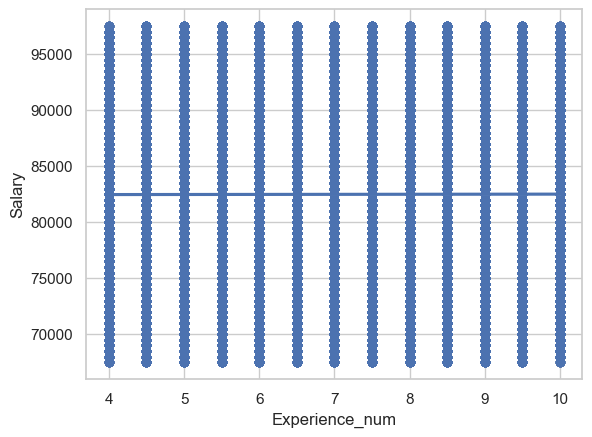

In [34]:
plt.figure()
sns.regplot(x="Experience_num", y="Salary", data=df, scatter_kws={"alpha":0.1})
plt.show()

The bivariate analysis shows high variability in the Salary variable when compared with the other variables; however, the distribution remains relatively balanced because the dataset is synthetic.

## Outlier Detection

In [35]:
q1 = df["Salary"].quantile(0.25)
q3 = df["Salary"].quantile(0.75)
iqr = q3 - q1

outliers = df[(df["Salary"] < q1 - 1.5 * iqr) | (df["Salary"] > q3 + 1.5 * iqr)]
len(outliers)

0

In [36]:
upper_limit = q3 + 1.5 * iqr
lower_limit = q1 - 1.5 * iqr

df["Salary_capped"] = df["Salary"].clip(lower_limit, upper_limit)

## Data Preprocessing

In [37]:
df = df.drop(columns=["Contact", "Contact Person", "Job Id"])

In [38]:
df["Company Size"] = pd.to_numeric(df["Company Size"], errors="coerce")

In [39]:
df = df.dropna(subset=["Salary"])

In [ ]:
sample_text = " ".join(df["Job Description"].sample(10000))
words = re.findall(r'\w+', sample_text.lower())

Counter(words).most_common(20)

[('and', 21907),
 ('to', 7773),
 ('they', 5910),
 ('a', 3531),
 ('the', 3135),
 ('in', 2852),
 ('with', 2676),
 ('data', 2357),
 ('ensure', 1975),
 ('for', 1917),
 ('user', 1831),
 ('of', 1808),
 ('on', 1786),
 ('or', 1575),
 ('support', 1394),
 ('create', 1381),
 ('design', 1369),
 ('provide', 1368),
 ('an', 1329),
 ('ensuring', 1244)]

## Feature Relevance Analysis

We evaluate feature importance using correlation and a tree-based model to identify the most relevant predictors of salary

In [41]:
model_df = df[[
    "Salary",
    "Experience_num",
    "Company Size",
    "desc_length",
    "skills_length",
    "resp_length",
    "skills_count",
    "Company_freq"
]].dropna()

In [42]:
X = model_df.drop(columns=["Salary"])
y = model_df["Salary"]

In [ ]:
model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [44]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances

Company Size      0.379854
Company_freq      0.212565
desc_length       0.100299
skills_length     0.098226
Experience_num    0.094282
resp_length       0.092865
skills_count      0.021908
dtype: float64

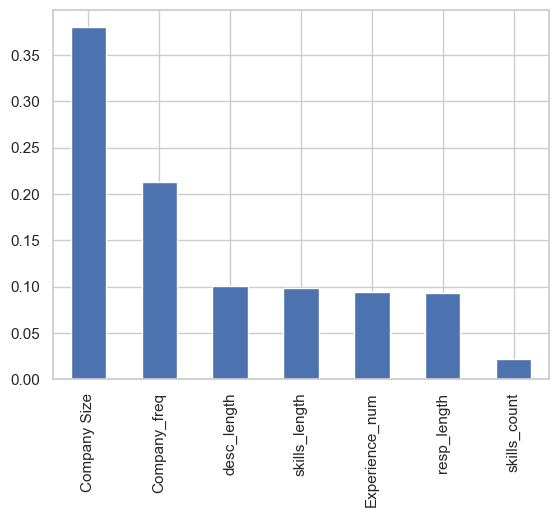

In [45]:
plt.figure()
importances.plot(kind="bar")
plt.show()

In [46]:
selected_features = importances[importances > 0.05].index.tolist()
print("the most important variables in order are: " + str(selected_features))

the most important variables in order are: ['Company Size', 'Company_freq', 'desc_length', 'skills_length', 'Experience_num', 'resp_length']


In [47]:
df_model = model_df[selected_features + ["Salary"]]
df_model.head()

,Company Size,Company_freq,desc_length,skills_length,Experience_num,resp_length,Salary
0,26801,1911,200,172,10.0,210,79000.0
1,100340,1812,231,85,7.0,220,86000.0
2,84525,1820,222,199,6.0,191,82500.0
3,129896,1801,200,185,7.5,186,78000.0
4,53944,1828,235,114,6.5,158,75500.0


# EDA Findings and Conclusions

## Missing Values

The dataset contains very few missing values. Only the `Company Profile` column presents missing entries, with 5,478 null values, representing approximately 0.34% of the dataset. All other variables are complete.

No strong missing-value patterns were identified, suggesting that the dataset is generally well-structured and suitable for analysis without aggressive imputation strategies.

---

## Summary Statistics

The dataset contains 1,615,940 job postings and 23 variables.

Key numerical observations:

- `Company Size` has a mean of approximately 73,704 employees.
- Latitude values range from -40.90 to 71.70.
- Longitude values range from -175.20 to 178.06.
- Salary ranges were transformed into numerical salary estimates for analysis.

Key categorical observations:

- `Qualifications` contains 10 categories.
- `Work Type` contains 5 categories.
- `Country` contains 216 unique values.
- `Company` contains 888 unique values.

The dataset combines structured numerical data with high-dimensional textual information.

---

## Outlier Analysis

Outlier detection was performed using the IQR method on the salary variable.

No significant salary outliers were identified under the standard 1.5 × IQR rule. However, salary distributions still exhibit moderate variability, suggesting that capped or transformed versions may still improve modeling stability.

---

## Cardinality of Categorical Variables

Several categorical variables exhibit high cardinality:

- `Contact`: 1,615,933 unique values
- `Contact Person`: 367,128 unique values
- `Company`: 888 unique values
- `Role`: 376 unique values
- `Job Description`: 376 unique values

These variables may negatively affect machine learning models if encoded directly. Frequency encoding or feature extraction techniques are more appropriate for these cases.

---

## Skewed Distributions and Transformations

The salary distribution showed moderate skewness. To reduce skewness and stabilize variance, a logarithmic transformation (`log1p`) was applied to the salary variable.

Text-based features such as job description length and skills length also exhibited non-normal distributions.

---

## Temporal Trends

The dataset includes a temporal variable: `Job Posting Date`.

After converting the column to datetime format, yearly posting trends were analyzed. The dataset mainly contains job postings from 2022 and 2023, with relatively stable posting activity over time.

No major seasonal fluctuations were observed at the yearly aggregation level.

---

## Correlation Analysis

Correlation analysis revealed generally weak to moderate relationships between numerical features and salary.

The most relevant engineered features included:

- `Experience_num`
- `Company Size`
- `skills_count`
- `desc_length`

Feature relevance analysis using a Random Forest model confirmed that experience-related and text-derived variables contributed more strongly to salary prediction than geographic variables.

---

## Bivariate Analysis

Several bivariate analyses were performed:

- Salary distribution by `Work Type`
- Salary distribution by `Experience`
- Relationship between experience and salary using scatterplots and regression plots

Results suggest that higher experience levels tend to correspond to higher salary ranges, although variability remains high across categories.

Different work types also show distinct salary distributions.

---

## Image Normalization

This dataset does not contain image data; therefore, image normalization was not required.

---

## Class Imbalance

The `Work Type` variable shows moderate class imbalance.

Some categories, such as `Part-Time`, appear significantly more frequently than others. This imbalance should be considered during future modeling stages, especially for classification tasks.

## General Conclusions

- The dataset is large, diverse, and mostly clean.
- Textual variables represent an important source of information.
- High-cardinality categorical variables require preprocessing strategies.
- Salary and experience exhibit meaningful relationships.
- Feature engineering significantly improves feature relevance analysis.
- The dataset is suitable for predictive modeling and NLP applications.
- The exploratory analysis suggests that the dataset can be extended with synthetic ranking labels associated with specific professional roles, such as Software Engineer, Data Scientist, or Product Manager.
- By incorporating ranking scores for each job posting, the dataset can be transformed into a supervised learning problem where the model learns to predict the relevance or quality ranking of a job opportunity given its role, skills, experience requirements, and description.
- This preprocessing and feature engineering pipeline provides a strong foundation for building a job recommendation or ranking system.

# Activity 2: Feature Engineering and Data Preparation for Machine Learning

In this section, we transform the raw job postings dataset into a structured dataset suitable for machine learning.

We perform feature extraction, encoding, scaling preparation, feature selection, and transformations to reduce skewness and improve model readiness.

This stage prepares the dataset for a future supervised learning system that will predict job compatibility scores.

## Feature Engineering and Data Preparation for Machine Learning

In this section, we transform the raw job postings dataset into a structured dataset suitable for machine learning.

We perform feature extraction, encoding, scaling preparation, feature selection, and transformations to reduce skewness and improve model readiness.

This stage prepares the dataset for a future supervised learning system that will predict job compatibility scores.

In [48]:
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

In [49]:
df["desc_length"] = df["Job Description"].str.len()
df["skills_length"] = df["skills"].str.len()
df["resp_length"] = df["Responsibilities"].str.len()

df["skills_count"] = df["skills"].apply(lambda x: len(str(x).split(",")))

df["Experience_num"] = df["Experience"].apply(
    lambda x: (int(x.split("to")[0]) + int(x.split("to")[1].replace("Years", "").strip())) / 2
)

In [50]:
df[["desc_length", "skills_length", "resp_length", "skills_count", "Experience_num"]].head(10)

,desc_length,skills_length,resp_length,skills_count,Experience_num
0,200,172,210,4,10.0
1,231,85,220,5,7.0
2,222,199,191,2,6.0
3,200,185,186,1,7.5
4,235,114,158,1,6.5
5,185,143,181,3,8.0
6,191,107,179,1,9.0
7,200,168,210,3,5.0
8,195,162,238,1,5.5
9,184,53,155,1,5.5


### 2. Outlier Detection using IQR

We detect outliers in numerical variables using the Interquartile Range (IQR) method.

In [51]:
numeric_cols = ["Company Size", "desc_length", "skills_length", "resp_length", "skills_count"]

outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

outlier_summary

{'Company Size': 0,
 'desc_length': 34813,
 'skills_length': 7115,
 'resp_length': 3422,
 'skills_count': 114820}

### 3. Distribution Transformations

We apply transformations to reduce skewness and improve stability for machine learning models.

In [52]:
df["Salary"] = df["Salary Range"].apply(clean_salary)
df["Salary_log"] = np.log1p(df["Salary"])

df[numeric_cols].skew()

Company Size     0.002142
desc_length      1.007489
skills_length    0.770081
resp_length     -0.017358
skills_count     2.691339
dtype: float64

### 4. Encoding High Cardinality Features

We apply frequency encoding to categorical variables with high cardinality such as Company.

In [53]:
company_freq = df["Company"].value_counts()
df["Company_freq"] = df["Company"].map(company_freq)

df["Company_freq"]

0          1911
1          1812
2          1820
3          1801
4          1828
           ... 
1615935    1862
1615936    1855
1615937    1870
1615938    1842
1615939    1875
Name: Company_freq, Length: 1615940, dtype: int64

### 5. Feature Scaling Preparation

We prepare numerical features for scaling to ensure compatibility with future ML models such as regression, clustering, and embeddings-based similarity.

In [54]:
scale_cols = [
    "Company Size",
    "Experience_num",
    "desc_length",
    "skills_length",
    "resp_length",
    "skills_count"
]

scaler = StandardScaler()
df_scaled = df.copy()

df_scaled[scale_cols] = scaler.fit_transform(df_scaled[scale_cols])

df_scaled[scale_cols].head(10)

,Company Size,Experience_num,desc_length,skills_length,resp_length,skills_count
0,-1.328759,2.100241,0.282772,0.560193,1.045450,1.771442
1,0.754566,0.000074,0.881880,-0.917254,1.481099,2.530350
2,0.306535,-0.699982,0.707945,1.018710,0.217718,0.253625
3,1.591874,0.350101,0.282772,0.780960,-0.000107,-0.505283
4,-0.559811,-0.349954,0.959184,-0.424772,-1.219923,-0.505283
5,-1.430887,0.700129,-0.007119,0.067710,-0.217931,1.012534
6,-1.348080,1.400185,0.108837,-0.543647,-0.305061,-0.505283
7,-0.939030,-1.400038,0.282772,0.492264,1.045450,1.012534
8,0.896299,-1.050010,0.186141,0.390371,2.265266,-0.505283
9,0.803548,-1.050010,-0.026445,-1.460683,-1.350617,-0.505283


### 6. Feature Selection using Random Forest Importance

We use a tree-based model to identify the most relevant features for predicting Salary as a proxy variable.

In [55]:
model_df = df[
    [
        "Salary",
        "Experience_num",
        "Company Size",
        "desc_length",
        "skills_length",
        "resp_length",
        "skills_count",
        "Company_freq"
    ]
].dropna()

X = model_df.drop(columns=["Salary"])
y = model_df["Salary"]

model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances

Company Size      0.379168
Company_freq      0.204210
skills_length     0.101221
desc_length       0.101121
Experience_num    0.097113
resp_length       0.095414
skills_count      0.021752
dtype: float64

We select features above a threshold to reduce dimensionality and improve generalization.

In [56]:
selected_features = importances[importances > 0.05].index.tolist()

df_model = model_df[selected_features + ["Salary"]]
df_model.head()

,Company Size,Company_freq,skills_length,desc_length,Experience_num,resp_length,Salary
0,26801,1911,172,200,10.0,210,79000.0
1,100340,1812,85,231,7.0,220,86000.0
2,84525,1820,199,222,6.0,191,82500.0
3,129896,1801,185,200,7.5,186,78000.0
4,53944,1828,114,235,6.5,158,75500.0


### 7. Correlation Analysis for Feature Validation

We validate relationships between selected features and the target variable.

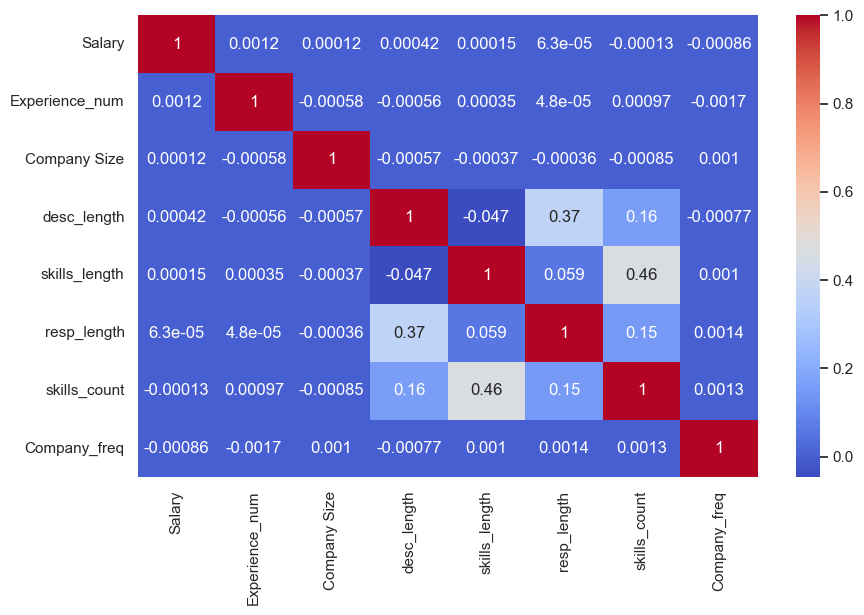

In [57]:
corr = model_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

### 8. Final ML-Ready Dataset

We construct the final dataset that will be used in future supervised learning stages. We'll need to modify some of the data to make it ML ready.

In [58]:
ml_columns = [
    "Experience",
    "Experience_num",
    "Qualifications",
    "Salary",
    "Salary_log",
    "location",
    "Country",
    "latitude",
    "longitude",
    "Work Type",
    "Company Size",
    "Preference",
    "Job Title",
    "Role",
    "Job Portal",
    "Job Description",
    "Benefits",
    "skills",
    "Responsibilities",
    "Company",
    "Company_freq",
    "Company Profile",
    "desc_length",
    "skills_length",
    "resp_length",
    "skills_count"
]

df_ml_ready = df[ml_columns].copy()

In [59]:
def extract_experience_ranges(exp):
    exp = exp.replace("Years", "").strip()

    parts = exp.split("to")

    exp_min = int(parts[0].strip())
    exp_max = int(parts[1].strip())

    exp_avg = (exp_min + exp_max) / 2

    return pd.Series([exp_min, exp_max, exp_avg])

df[["Experience_min", "Experience_max", "Experience_avg"]] = (
    df["Experience"].apply(extract_experience_ranges)
)

In [60]:
def parse_company_profile(profile):
    try:
        data = json.loads(profile)

        sector = data.get("Sector", np.nan)
        industry = data.get("Industry", np.nan)
        state = data.get("State", np.nan)

        has_ticker = 0 if data.get("Ticker", "") == "" else 1
        has_website = 0 if data.get("Website", "") == "" else 1

        return pd.Series([
            sector,
            industry,
            state,
            has_ticker,
            has_website
        ])

    except:
        return pd.Series([np.nan]*5)

df[[
    "Company_Sector",
    "Company_Industry",
    "Company_State",
    "Has_Ticker",
    "Has_Website"
]] = df["Company Profile"].apply(parse_company_profile)

In [61]:
df["benefits_count"] = df["Benefits"].apply(
    lambda x: len(str(x).replace("{","").replace("}","").split(","))
)

In [62]:
df["skills_word_count"] = df["skills"].apply(
    lambda x: len(str(x).split())
)

In [63]:
df["job_desc_word_count"] = df["Job Description"].apply(
    lambda x: len(str(x).split())
)

In [64]:
df["resp_word_count"] = df["Responsibilities"].apply(
    lambda x: len(str(x).split())
)

In [65]:
final_columns = [
    # -----------------------
    # IDENTIFIERS / META
    # -----------------------
    "Qualifications",
    "Work Type",
    "Preference",
    "Job Title",
    "Role",
    "Job Portal",

    # -----------------------
    # EXPERIENCE (ENGINEERED)
    # -----------------------
    "Experience_min",
    "Experience_max",
    "Experience_avg",

    # -----------------------
    # SALARY
    # -----------------------
    "Salary",
    "Salary_log",

    # -----------------------
    # GEOGRAPHY
    # -----------------------
    "location",
    "Country",
    "latitude",
    "longitude",

    # -----------------------
    # COMPANY STRUCTURE
    # -----------------------
    "Company",
    "Company Size",
    "Company_freq",

    "Company_Sector",
    "Company_Industry",
    "Company_State",
    "Has_Ticker",
    "Has_Website",

    # -----------------------
    # TEXT FEATURES (ENGINEERED)
    # -----------------------
    "desc_length",
    "skills_length",
    "resp_length",
    "skills_count",
    "skills_word_count",
    "job_desc_word_count",
    "resp_word_count",
    "benefits_count",

    # -----------------------
    # RAW TEXT (KEEP FOR NLP)
    # -----------------------
    "Job Description",
    "skills",
    "Responsibilities",
    "Benefits",
    "Company Profile"
]

In [66]:
df_final = df[final_columns].copy()

In [67]:
print(df_final.shape)
print(df_final.columns)
df_final.head()

(1615940, 36)
Index(['Qualifications', 'Work Type', 'Preference', 'Job Title', 'Role',
       'Job Portal', 'Experience_min', 'Experience_max', 'Experience_avg',
       'Salary', 'Salary_log', 'location', 'Country', 'latitude', 'longitude',
       'Company', 'Company Size', 'Company_freq', 'Company_Sector',
       'Company_Industry', 'Company_State', 'Has_Ticker', 'Has_Website',
       'desc_length', 'skills_length', 'resp_length', 'skills_count',
       'skills_word_count', 'job_desc_word_count', 'resp_word_count',
       'benefits_count', 'Job Description', 'skills', 'Responsibilities',
       'Benefits', 'Company Profile'],
      dtype='str')


,Qualifications,Work Type,Preference,Job Title,Role,Job Portal,Experience_min,Experience_max,Experience_avg,Salary,...,skills_count,skills_word_count,job_desc_word_count,resp_word_count,benefits_count,Job Description,skills,Responsibilities,Benefits,Company Profile
0,M.Tech,Intern,Female,Digital Marketing Specialist,Social Media Manager,Snagajob,5.0,15.0,10.0,79000.0,...,4,21,28,29,5,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising","Manage and grow social media accounts, create engaging content, and interact with the online community. Develop social media content calendars and strategies. Monitor social media trends and engagement metrics.","{'Flexible Spending Accounts (FSAs), Relocation Assistance, Legal Assistance, Employee Recognition Programs, Financial Counseling'}","{""Sector"":""Diversified"",""Industry"":""Diversified Financials"",""City"":""Sunny Isles Beach"",""State"":""Florida"",""Zip"":""33160"",""Website"":""www.ielp.com"",""Ticker"":""IEP"",""CEO"":""David Willetts""}"
1,BCA,Intern,Female,Web Developer,Frontend Web Developer,Idealist,2.0,12.0,7.0,86000.0,...,5,11,31,29,5,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.","HTML, CSS, JavaScript Frontend frameworks (e.g., React, Angular) User experience (UX)","Design and code user interfaces for websites, ensuring a seamless and visually appealing user experience. Collaborate with UX designers to optimize user journeys. Ensure cross-browser compatibility and responsive design.","{'Health Insurance, Retirement Plans, Paid Time Off (PTO), Flexible Work Arrangements, Employee Assistance Programs (EAP)'}","{""Sector"":""Financial Services"",""Industry"":""Commercial Banks"",""City"":""Pittsburgh"",""State"":""Pennsylvania"",""Zip"":""15222"",""Website"":""www.pnc.com"",""Ticker"":""PNC"",""CEO"":""William S. Demchak""}"
2,PhD,Temporary,Male,Operations Manager,Quality Control Manager,Jobs2Careers,0.0,12.0,6.0,82500.0,...,2,25,28,24,5,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.","Quality control processes and methodologies Statistical process control (SPC) Root cause analysis and corrective action Quality management systems (e.g., ISO 9001) Compliance and regulatory knowledge",Establish and enforce quality control standards and procedures. Conduct quality audits and inspections. Collaborate with production teams to address quality issues and implement improvements.,"{'Legal Assistance, Bonuses and Incentive Programs, Wellness Programs, Employee Discounts, Retirement Plans'}","{""Sector"":""Insurance"",""Industry"":""Insurance: Property and Casualty (Stock)"",""City"":""San Antonio"",""State"":""Texas"",""Zip"":""78288"",""Website"":""www.usaa.com"",""Ticker"":"""",""CEO"":""Wayne Peacock""}"
3,PhD,Full-Time,Female,Network Engineer,Wireless Network Engineer,FlexJobs,4.0,11.0,7.5,78000.0,...,1,22,23,22,5,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.",Wireless network design and architecture Wi-Fi standards and protocols RF (Radio Frequency) planning and optimization Wireless security protocols Troubleshooting wireless network issues,"Design, configure, and optimize wireless networks, ensuring reliable and secure wireless connectivity. Trou

In [68]:
os.makedirs("../data/output", exist_ok=True)
df_final.to_csv("../data/output/featured_engineered_dataset.csv", index=False)

This are the columns that the model will use for training:

In [69]:
model_columns = [
    # EXPERIENCE
    "Experience_min",
    "Experience_max",
    "Experience_avg",

    # SALARY (only if NOT target)
    "Salary",
    "Salary_log",

    # COMPANY STRUCTURE
    "Company Size",
    "Company_freq",

    # TEXT-BASED ENGINEERED FEATURES
    "desc_length",
    "skills_length",
    "resp_length",
    "skills_count",
    "skills_word_count",
    "job_desc_word_count",
    "resp_word_count",
    "benefits_count",

    # GEO (optional but OK)
    "latitude",
    "longitude",

    # COMPANY STRUCTURED INFO
    "Has_Ticker",
    "Has_Website"
]

## Data Preparation Summary (CRISP-ML Phase)

During the data preparation phase, the original job postings dataset was transformed into a structured and feature-rich dataset suitable for machine learning and natural language processing tasks.

### Feature Engineering and Transformations

Several feature engineering steps were applied to improve the dataset's predictive and analytical capacity:

- Text-based features were extracted from unstructured fields such as Job Description, Skills, and Responsibilities, including:
  - Character and word-based length metrics
  - Skill count and textual complexity indicators
- The Experience field was decomposed into numerical representations:
  - Experience_min
  - Experience_max
  - Experience_avg
- Salary values were cleaned and transformed into a numerical format and a log-transformed version (Salary_log) to reduce scale effects and improve distribution stability.
- Company-related information was enriched using frequency encoding (Company_freq) and structured parsing of Company Profile into:
  - Sector
  - Industry
  - State
  - Binary indicators for presence of ticker and website

### Data Quality and Preparation

- Missing values were minimal and did not require aggressive imputation strategies.
- High-cardinality categorical variables were identified and either retained for analysis or encoded appropriately.
- No significant outliers were detected in salary using the IQR method.
- Text fields were preserved for future NLP and embedding-based similarity modeling.

### Final Dataset Structure

The resulting dataset was organized into three main types of features:

1. Structured numerical and categorical features for machine learning models.
2. Engineered text-derived features for improved representation of job complexity.
3. Raw text fields preserved for NLP tasks such as embeddings and semantic similarity.

This hybrid structure ensures compatibility with both classical machine learning models and modern NLP-based recommender systems.

### Next Steps: Synthetic Data Generation

Since the dataset does not contain explicit labels for job relevance or compatibility, a synthetic labeling strategy will be implemented to enable supervised learning.

Two key target variables will be created:

- **Job_Family**: A categorical label representing the professional domain of each job (e.g., Software Engineering, Data Science, Marketing, Healthcare). This will be generated using rule-based classification and keyword/skills mapping.

- **Compatibility_Score (1–5)**: A synthetic target variable representing the alignment between a job posting and an ideal candidate profile. This score will be derived using:
  - Skill overlap between job descriptions and predefined profiles
  - Experience level compatibility
  - Semantic similarity (future step using embeddings)

These synthetic labels will allow the transformation of the dataset into a supervised learning problem for training a job ranking and recommendation model.

### CRISP-ML Context

This phase completes the data preparation stage of CRISP-ML by producing a clean, structured, and model-ready dataset. The next phase will focus on synthetic labeling, followed by model training for job ranking and recommendation.